# Setup


In [ ]:
import os
import numpy as np
import random
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt


# Reproductibilité + chemins

In [ ]:


SEED = 42
random.seed(SEED)
np.random.seed(SEED)



COCOBG_PATH = "/content/drive/MyDrive/Colab Notebooks/coco_background_embeddings.npy"
DOTABG_PATH = "/content/drive/MyDrive/Colab Notebooks/dota_background_embeddings.npy"
DOTA_PATH = "/content/drive/MyDrive/Colab Notebooks/dota__embeddings.npy"
DIOR_PATH = "/content/drive/MyDrive/Colab Notebooks/dior_embeddings.npy"

# Options
TEST_SIZE = 0.2
VAL_SIZE = 0.2     # sur le train, pour early stop MLP (si activé)
STRATIFY = True

#print("COCO_PATH:", COCO_PATH)
print("DOTA_PATH:", DOTA_PATH)
print("DIOR_PATH:", DIOR_PATH)

DOTA_PATH: /content/drive/MyDrive/Colab Notebooks/dota__embeddings.npy
DIOR_PATH: /content/drive/MyDrive/Colab Notebooks/dior_embeddings.npy


# Chargement embeddings (npy/npz/pt)

In [ ]:
def load_embeddings(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        arr = np.load(path)
        return arr
    if ext == ".npz":
        data = np.load(path)
        # essaie des clés communes, sinon prend la première
        for k in ["embeddings", "x", "X", "feat", "features"]:
            if k in data:
                return data[k]
        return data[list(data.keys())[0]]
    if ext == ".pt":
        t = torch.load(path, map_location="cpu")
        # support dict ou tensor
        if isinstance(t, dict):
            for k in ["embeddings", "x", "X", "feat", "features"]:
                if k in t:
                    t = t[k]
                    break
            else:
                # première valeur du dict
                t = next(iter(t.values()))
        if isinstance(t, torch.Tensor):
            return t.detach().cpu().numpy()
        return np.asarray(t)
    raise ValueError(f"Extension non supportée: {ext}")

X_coco = load_embeddings(COCO_PATH)
X_dota = load_embeddings(DOTA_PATH)
X_dior = load_embeddings(DIOR_PATH)

#print("COCO embeddings:", X_coco.shape, X_coco.dtype)
print("DOTA embeddings:", X_dota.shape, X_dota.dtype)
print("DIOR embeddings:", X_dior.shape, X_dior.dtype)

assert X_coco.ndim == 2 and X_dota.ndim == 2 and X_dior.ndim == 2, "Embeddings doivent être (N, D)"
assert X_coco.shape[1] == X_dota.shape[1] == X_dior.shape[1], "Dimension D différente entre COCO, DOTA et DIOR"

DOTA embeddings: (50, 2048) float32
DIOR embeddings: (50, 2048) float32


# Préparation dataset binaire “domaine”

In [ ]:
# Old comparison (disabled)
# y_coco = np.zeros((X_coco.shape[0],), dtype=np.int64)
# y_dota = np.ones((X_dota.shape[0],), dtype=np.int64)
# X = np.vstack([X_coco, X_dota]).astype(np.float32)
# y = np.concatenate([y_coco, y_dota])
# print("Total (COCO vs DOTA):", X.shape, "labels:", np.bincount(y))

# New comparison: DOTA vs DIOR
y_dota_new = np.zeros((X_dota.shape[0],), dtype=np.int64) # DOTA as source (0)
y_dior = np.ones((X_dior.shape[0],), dtype=np.int64)     # DIOR as target (1)

X = np.vstack([X_dota, X_dior]).astype(np.float32)
y = np.concatenate([y_dota_new, y_dior])

print("Total (DOTA vs DIOR):", X.shape, "labels:", np.bincount(y))

Total (DOTA vs DIOR): (100, 2048) labels: [50 50]


# Split train/test + normalisation

In [ ]:
strat = y if STRATIFY else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=strat
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train_s.shape, np.bincount(y_train))
print("Test :", X_test_s.shape,  np.bincount(y_test))


Train: (80, 2048) [40 40]
Test : (20, 2048) [10 10]


# Logistic Regression

In [ ]:
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)
logreg.fit(X_train_s, y_train)

proba_test = logreg.predict_proba(X_test_s)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

acc = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, proba_test)

print(f"[LogReg] Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")


[LogReg] Accuracy: 0.7000 | ROC-AUC: 0.7800


# Proxy A-distance

In [ ]:
err = 1.0 - acc
pad = 2.0 * (1.0 - 2.0 * err)
pad = float(np.clip(pad, 0.0, 2.0))

print(f"Error ε: {err:.4f}")
print(f"Proxy A-distance (PAD): {pad:.4f}  (0=proche, 2=très différent)")


Error ε: 0.3000
Proxy A-distance (PAD): 0.8000  (0=proche, 2=très différent)


# Courbe ROC (LogReg)

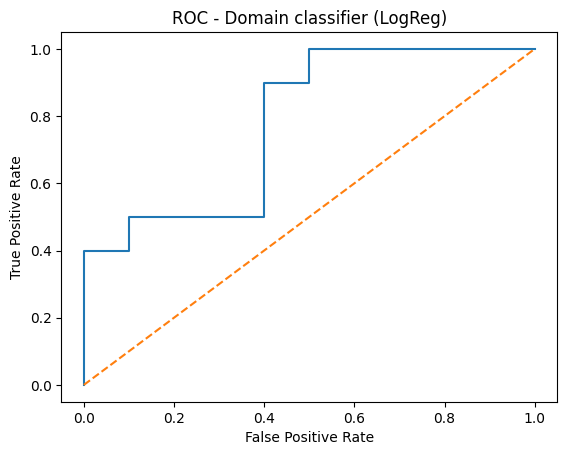

In [ ]:
fpr, tpr, thr = roc_curve(y_test, proba_test)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Domain classifier (LogReg)")
plt.show()


# MLP PyTorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Split train -> train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_s, y_train, test_size=VAL_SIZE, random_state=SEED, stratify=y_train
)

X_tr_t  = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)  # BCE expects float
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_te_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_te_t  = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=512, shuffle=False)

class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # logits
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP(X.shape[1]).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.BCEWithLogitsLoss()

def eval_loader(loader):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits)
            probs.append(p.detach().cpu().numpy())
            ys.append(yb.detach().cpu().numpy())
    probs = np.concatenate(probs)
    ys = np.concatenate(ys).astype(int)
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(ys, preds)
    auc = roc_auc_score(ys, probs)
    return acc, auc, probs, ys

best_val_auc = -1
best_state = None
patience = 10
pat = 0
EPOCHS = 100

for epoch in range(1, EPOCHS+1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()

    val_acc, val_auc, _, _ = eval_loader(val_loader)
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | val_acc={val_acc:.4f} val_auc={val_auc:.4f} | best_val_auc={best_val_auc:.4f}")

    if pat >= patience:
        print("Early stopping.")
        break

# restore best
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})


device: cpu
Epoch 001 | val_acc=0.5000 val_auc=0.4688 | best_val_auc=0.4688
Epoch 005 | val_acc=0.5625 val_auc=0.4688 | best_val_auc=0.5156
Epoch 010 | val_acc=0.5625 val_auc=0.4688 | best_val_auc=0.5156
Early stopping.


<All keys matched successfully>

# Évaluation MLP + PAD

[MLP] Accuracy: 0.5500 | ROC-AUC: 0.6900
Error ε: 0.4500
Proxy A-distance (PAD): 0.2000


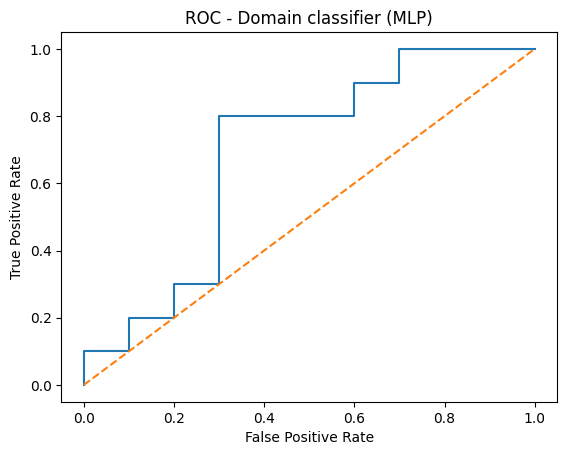

In [ ]:
test_acc, test_auc, test_probs, test_ys = eval_loader(test_loader)

print(f"[MLP] Accuracy: {test_acc:.4f} | ROC-AUC: {test_auc:.4f}")

err = 1.0 - test_acc
pad = 2.0 * (1.0 - 2.0 * err)
pad = float(np.clip(pad, 0.0, 2.0))

print(f"Error ε: {err:.4f}")
print(f"Proxy A-distance (PAD): {pad:.4f}")

fpr, tpr, _ = roc_curve(test_ys, test_probs)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Domain classifier (MLP)")
plt.show()
